# VGG16 실습

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data.dataloader import DataLoader
from torch.optim.adam import Adam
from torchvision.datasets.cifar import CIFAR10
from torchvision.transforms import Compose
from torchvision.transforms import RandomCrop, RandomHorizontalFlip, Normalize
import torchvision.transforms as T

In [4]:
transforms = Compose([
    RandomCrop((32,32), padding=4), #과적합 방지를 위해 랜덤성부여
    RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.243, 0.261))
])

In [6]:
train_data = CIFAR10(root='../../data_resources/', train=True, download=True, transform=transforms)
test_data = CIFAR10(root='../../data_resources/', train=False, download=True, transform=transforms)

100.0%


In [10]:
train_data.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [8]:
train_data.targets[0]

6

In [9]:
train_data.data[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [11]:
train_data.data[0].shape

(32, 32, 3)

In [13]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [18]:
img_data = iter(train_loader)
imgs, labels = next(img_data)

imgs.shape
imgs[0]



tensor([[[-1.9895, -1.9895, -1.9895,  ..., -1.9895, -1.9895, -1.9895],
         [-0.0366,  0.0745,  0.1221,  ..., -1.9895, -1.9895, -1.9895],
         [-0.0208,  0.0904,  0.1539,  ..., -1.9895, -1.9895, -1.9895],
         ...,
         [ 0.0904,  0.1539,  0.2333,  ..., -1.9895, -1.9895, -1.9895],
         [ 0.0745,  0.1380,  0.2174,  ..., -1.9895, -1.9895, -1.9895],
         [ 0.0586,  0.1063,  0.1856,  ..., -1.9895, -1.9895, -1.9895]],

        [[-1.9844, -1.9844, -1.9844,  ..., -1.9844, -1.9844, -1.9844],
         [ 1.0819,  1.1303,  1.1787,  ..., -1.9844, -1.9844, -1.9844],
         [ 1.0980,  1.1464,  1.2110,  ..., -1.9844, -1.9844, -1.9844],
         ...,
         [ 1.1626,  1.2110,  1.2755,  ..., -1.9844, -1.9844, -1.9844],
         [ 1.1787,  1.2110,  1.2594,  ..., -1.9844, -1.9844, -1.9844],
         [ 1.1464,  1.2110,  1.2594,  ..., -1.9844, -1.9844, -1.9844]],

        [[-1.7107, -1.7107, -1.7107,  ..., -1.7107, -1.7107, -1.7107],
         [ 1.9404,  1.9855,  2.0155,  ..., -1

In [22]:
img_data = imgs[0]
img_data = img_data.numpy()
img_data

array([[[-1.9894737 , -1.9894737 , -1.9894737 , ..., -1.9894737 ,
         -1.9894737 , -1.9894737 ],
        [-0.03662778,  0.07450991,  0.1221403 , ..., -1.9894737 ,
         -1.9894737 , -1.9894737 ],
        [-0.02075098,  0.0903867 ,  0.15389389, ..., -1.9894737 ,
         -1.9894737 , -1.9894737 ],
        ...,
        [ 0.0903867 ,  0.15389389,  0.23327787, ..., -1.9894737 ,
         -1.9894737 , -1.9894737 ],
        [ 0.07450991,  0.13801709,  0.21740107, ..., -1.9894737 ,
         -1.9894737 , -1.9894737 ],
        [ 0.05863312,  0.1062635 ,  0.18564747, ..., -1.9894737 ,
         -1.9894737 , -1.9894737 ]],

       [[-1.9843621 , -1.9843621 , -1.9843621 , ..., -1.9843621 ,
         -1.9843621 , -1.9843621 ],
        [ 1.081885  ,  1.1302994 ,  1.1787138 , ..., -1.9843621 ,
         -1.9843621 , -1.9843621 ],
        [ 1.0980232 ,  1.1464375 ,  1.2109902 , ..., -1.9843621 ,
         -1.9843621 , -1.9843621 ],
        ...,
        [ 1.1625757 ,  1.2109902 ,  1.2755427 , ..., -

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1206896].


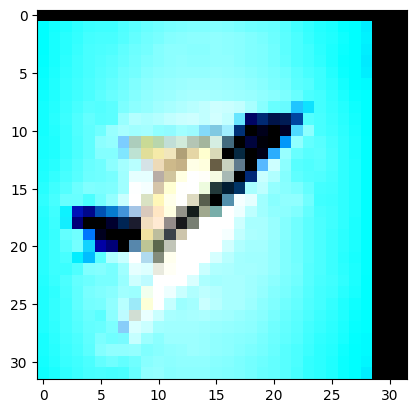

In [23]:
import numpy as np
import matplotlib.pyplot as plt
plt.imshow(np.transpose(img_data,(1,2,0)))
plt.show()


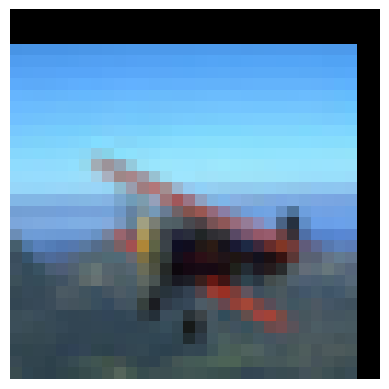

In [31]:
#반정규화
def denormalize(img, mean, std):
    mean = torch.tensor(mean).view(3,1,1)
    std = torch.tensor(std).view(3,1,1)
    return img * std + mean

#이미지 한장 출력
def view_image(img):
    mean = (0.4914, 0.4822, 0.4465)
    std = (0.247, 0.243, 0.261)

    image_data = denormalize(img, mean, std)
    image_data = image_data.numpy()
    plt.imshow(np.transpose(image_data,(1,2,0)))
    plt.axis('off')
    plt.show()

view_image(imgs[27])


## VGG16 직접 만들어보기

In [43]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1) # 3, 64
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        return x
        

In [ ]:
class Vgg16(nn.Module):
    def __init__(self, num_classes):
        super(Vgg16, self).__init__()

        self.block1 = BasicBlock(in_channels=3, out_channels=32, hidden_dim=64) #16
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64) #8
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128) #4

        # 최종 추출된 특징 256 * 4 * 4 = 4096
        self.fc1 = nn.Linear(in_features=4096, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = torch.flatten(x, 1)                   # (N,4096)
        # x = x.view(-1, 4096)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

model = Vgg16(10)

In [47]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()
from tqdm.auto import tqdm

lr = 1e-3
optim = Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
epochs = 10
step = 0

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

for epoch in range(epochs):
    for data, label in tqdm(train_loader):
        optim.zero_grad()

        preds = model(data.to(device))
        loss = criterion(preds, label.to(device))

        loss.backward()
        optim.step()

        writer.add_scalar("Loss/train", loss.item(), step)
        step +=1

    print(f"{epoch} loss: {loss.item()}")

  0%|          | 0/1563 [00:00<?, ?it/s]

0 loss: 1.3910245895385742


  0%|          | 0/1563 [00:00<?, ?it/s]

1 loss: 1.4155616760253906


  0%|          | 0/1563 [00:00<?, ?it/s]

...

7 loss: 0.9970869421958923


  0%|          | 0/1563 [00:00<?, ?it/s]

8 loss: 0.5700924396514893


  0%|          | 0/1563 [00:00<?, ?it/s]

9 loss: 1.4794418811798096


## 만들어진 VGG16 모델을 가져다 쓰기 (파인튜닝)

In [49]:
from torchvision.models.vgg import vgg16

model = vgg16(pretrained=True) # 이미 최적화로 학습된 가중치를 사용하겠다.
print(model)

c:\Users\user\potenup\python7month\DL\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\potenup\python7month\DL\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [50]:
# 내 데이터셋에 맞는 분류기를 생성해야함
fc = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 10)
)

In [52]:
model.classifier = fc
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
model.to(device)

lr = 1e-3
criterion = nn.CrossEntropyLoss()
epochs = 20
optim = Adam(model.parameters(), lr=lr)
step = 0

for epoch in range(epochs):

    for data, labels in tqdm(train_loader):
        optim.zero_grad()

        preds = model(data.to(device))
        loss = criterion(preds, labels.to(device))

        loss.backward()
        optim.step()

        writer.add_scalar("Loss/train", loss.item(), step)
        step+=1
    
    print(f"{epoch}- loss: {loss.item()}")

  0%|          | 0/1563 [00:00<?, ?it/s]

KeyboardInterrupt: 